# Testing across multiple products

## Level 3

* WORKS `short_name="ECCO_L4_SSH_05DEG_MONTHLY_V4R4"` level 4, ECCO Sea Surface Height - Monthly Mean 0.5 Degree (Version 4 Release 4)
* WORKS `short_name="MUR-JPL-L4-GLOB-v4.1"` level 4 SST
* WORKS `short_name="MUR25-JPL-L4-GLOB-v04.2"` level 4 SST
* WORKS `short_name = "TEMPO_NO2_L3", version = "V03"` level 3 [notebook](https://nasa.github.io/ASDC_Data_and_User_Services/TEMPO/how_to_examine_TEMPO_data_using_earthaccess.html)

## Level 2

* `concept_id = "C1962643459-LARC_ASDC"` level 2 [notebook](https://nasa.github.io/ASDC_Data_and_User_Services/DSCOVR/how_to_explore_aerosol_data_from_EPIC_and_EPA-AQS.html)
* `short_name="ATL03"` level 2, icesat-2. [notebook](https://nasa-openscapes.github.io/earthdata-cloud-cookbook/tutorials/Harmony.html)
* `short_name = "PREFIRE_SAT2_2B-CLD"` level 2 [notebook](https://nasa.github.io/ASDC_Data_and_User_Services/PREFIRE/plot_PREFIRE_L2_CLD_with_earthaccess_and_Harmony.html)
* `short_name = "DSCOVR_EPIC_L2_AER"` level 2 [notebook](https://nasa.github.io/ASDC_Data_and_User_Services/DSCOVR/how_to_compare_TEMPO_with_DSCOVR_and_AERONET_uvai.html)
* `short_name = "TEMPO_O3TOT_L2"` level 2 [notebook](https://nasa.github.io/ASDC_Data_and_User_Services/DSCOVR/how_to_compare_spatially_TEMPO_with_DSCOVR_uvai.html) [notebook](https://nasa.github.io/ASDC_Data_and_User_Services/DSCOVR/how_to_compare_TEMPO_with_DSCOVR_and_AERONET_uvai.html)
* `short_name = "DSCOVR_EPIC_L2_TO3", version = "03"` level 2 [notebook](https://nasa.github.io/ASDC_Data_and_User_Services/DSCOVR/how_to_plot_ozone_product_parameters.html)


### Special cases

* `short_name = "CAL_LID_L1-Standard-V4-51", version = "V4-51"` level 1b  Cloud-Aerosol Lidar and Infrared Pathfinder Satellite Observations (CALIPSO) [notebook](https://nasa.github.io/ASDC_Data_and_User_Services/CALIPSO/how_to_plot_ozone_number_densities.html)
* `short_name=['HLSL30','HLSS30']` Harmonized Landsat Sentinel-2 (HLS) data [notebook](https://nasa-openscapes.github.io/earthdata-cloud-cookbook/tutorials/Observing_Seasonal_Ag_Changes.html) These are tifs. Need different kind of opening.
  

## Create some points

Random global.

## ICESAT-2 ATL21

This h5 grouped data files. Somewhat horribly it has monthly, daily, and metadata all crammed together.

* to do, need to be able to customize the datatree-merge step to reliably deal with level 2 files

In [2]:
import pandas as pd
df_points = pd.read_csv(
    "fixtures/points_1000.csv",
    parse_dates=["time"]
)
df = df_points[
    (df_points["time"].dt.year == 2024)
]
len(df)

31

In [3]:
import point_collocation as pc
import pandas as pd
short_name="ATL21"
plan = pc.plan(
    df,
    data_source="earthaccess",
    source_kwargs={
        "short_name": short_name,
    }
)

In [5]:
plan.summary()

Plan: 31 points → 16 unique granule(s)
  Points with 0 matches : 20
  Points with >1 matches: 8
  Time buffer: 0 days 00:00:00

First 5 point(s):
  [35] lat=9.1007, lon=11.2167, time=2024-07-21 00:00:00: 0 match(es)
  [43] lat=-67.2099, lon=-62.7344, time=2024-04-16 00:00:00: 2 match(es)
    → https://data.nsidc.earthdatacloud.nasa.gov/nsidc-cumulus-prod-protected/ATLAS/ATL21/003/2024/04/01/ATL21-02_20240401012953_02052301_003_01.h5
    → https://data.nsidc.earthdatacloud.nasa.gov/nsidc-cumulus-prod-protected/ATLAS/ATL21/004/2024/04/01/ATL21-02_20240401012953_02052301_004_01.h5
  [83] lat=87.2283, lon=-29.7183, time=2024-10-13 00:00:00: 2 match(es)
    → https://data.nsidc.earthdatacloud.nasa.gov/nsidc-cumulus-prod-protected/ATLAS/ATL21/003/2024/10/01/ATL21-01_20241001001458_02252501_003_01.h5
    → https://data.nsidc.earthdatacloud.nasa.gov/nsidc-cumulus-prod-protected/ATLAS/ATL21/004/2024/10/01/ATL21-01_20241001001458_02252501_004_01.h5
  [190] lat=34.7017, lon=-20.0403, time=2024-04

In [15]:
icesat = {
    'xarray_open': 'datatree',
    'merge': ['/', '/monthly'],
    'open_kwargs': {'chunks': {}, 'engine': 'h5netcdf', 'decode_timedelta': False, 'phony_dims': 'sort'},
    'coords': {'lat': 'grid_lat', 'lon': 'grid_lon'},
    'set_coords': True,
}

In [16]:
%%time
plan.show_variables(open_method=icesat)

open_method: {'xarray_open': 'datatree', 'merge': ['/', '/monthly'], 'open_kwargs': {'chunks': {}, 'engine': 'h5netcdf', 'decode_timedelta': False, 'phony_dims': 'sort'}, 'coords': {'lat': 'grid_lat', 'lon': 'grid_lon'}, 'set_coords': True, 'dim_renames': None, 'auto_align_phony_dims': None, 'merge_kwargs': {}}

Dimensions: {'grid_y': 448, 'grid_x': 304, 'phony_dim_34': 1}

Variables: ['crs', 'grid_lat', 'grid_lon', 'land_mask_map', 'delta_time_beg', 'delta_time_end', 'mean_ssha', 'mean_weighted_earth_free2mean', 'mean_weighted_geoid', 'mean_weighted_geoid_free2mean', 'mean_weighted_mss', 'n_refsurfs', 'sigma']

Geolocation: NONE detected with open_method={'xarray_open': 'datatree', 'merge': ['/', '/monthly'], 'open_kwargs': {'chunks': {}, 'engine': 'h5netcdf', 'decode_timedelta': False, 'phony_dims': 'sort'}, 'coords': {'lat': 'grid_lat', 'lon': 'grid_lon'}, 'set_coords': True, 'dim_renames': None, 'auto_align_phony_dims': None, 'merge_kwargs': {}}. Try open_method='datatree-merge' or

In [10]:
import earthaccess
results = earthaccess.search_data(
    short_name="ATL21"
)
print(len(results))
f = earthaccess.open(results[0:2])

320


QUEUEING TASKS | :   0%|          | 0/2 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/2 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/2 [00:00<?, ?it/s]

In [12]:
%%time
import xarray as xr
dt = xr.open_datatree(f[1], decode_timedelta=False, phony_dims='sort')
dt

CPU times: user 30.9 s, sys: 69.8 ms, total: 31 s
Wall time: 31.7 s


<xarray.DataTree>
Group: /
│   Dimensions:        (grid_y: 448, grid_x: 304)
│   Coordinates:
│     * grid_y         (grid_y) float64 4kB 5.838e+06 5.812e+06 ... -5.338e+06
│     * grid_x         (grid_x) float64 2kB -3.838e+06 -3.812e+06 ... 3.738e+06
│   Data variables:
│       crs            int8 1B ...
│       grid_lat       (grid_y, grid_x) float64 1MB ...
│       grid_lon       (grid_y, grid_x) float64 1MB ...
│       land_mask_map  (grid_y, grid_x) float64 1MB ...
│   Attributes: (12/46)
│       short_name:                         ATL21
│       level:                              L3B
│       description:                        This data set (ATL21) contains daily ...
│       Conventions:                        CF-1.7
│       contributor_name:                   Alek Petty (alek.a.petty@nasa.gov), R...
│       contributor_role:                   Investigator, Investigator, Investiga...
│       ...                                 ...
│       processing_level:                   3B
│       references:                         http://nsidc.org/data/icesat2/data.html
│       project:                            ICESat-2 > Ice, Cloud, and land Eleva...
│       instrument:                         ATLAS > Advanced Topographic Laser Al...
│       platform:                           ICESat-2 > Ice, Cloud, and land Eleva...
│       source:                             Spacecraft
├── Group: /ancillary_data
│   │   Dimensions:              (phony_dim_2: 1)
│   │   Dimensions without coordinates: phony_dim_2
│   │   Data variables: (12/24)
│   │       atlas_sdp_gps_epoch  (phony_dim_2) datetime64[ns] 8B ...
│   │       control              (phony_dim_2) |S100000 100kB ...
│   │       data_end_utc         (phony_dim_2) |S27 27B ...
│   │       data_start_utc       (phony_dim_2) |S27 27B ...
│   │       end_cycle            (phony_dim_2) int32 4B ...
│   │       end_delta_time       (phony_dim_2) datetime64[ns] 8B ...
│   │       ...                   ...
│   │       start_gpssow         (phony_dim_2) float64 8B ...
│   │       start_gpsweek        (phony_dim_2) int32 4B ...
│   │       start_orbit          (phony_dim_2) int32 4B ...
│   │       start_region         (phony_dim_2) int32 4B ...
│   │       start_rgt            (phony_dim_2) int32 4B ...
│   │       version              (phony_dim_2) |S80 80B ...
│   │   Attributes:
│   │       description:  Contains information ancillary to the data product. This ma...
│   ├── Group: /ancillary_data/beam_selection
│   │       Dimensions:            (phony_dim_3: 1)
│   │       Dimensions without coordinates: phony_dim_3
│   │       Data variables:
│   │           proc_atl21_spot_1  (phony_dim_3) int8 1B ...
│   │           proc_atl21_spot_2  (phony_dim_3) int8 1B ...
│   │           proc_atl21_spot_3  (phony_dim_3) int8 1B ...
│   │           proc_atl21_spot_4  (phony_dim_3) int8 1B ...
│   │           proc_atl21_spot_5  (phony_dim_3) int8 1B ...
│   │           proc_atl21_spot_6  (phony_dim_3) int8 1B ...
│   │       Attributes:
│   │           description:  These parameters control which laser beam spots from ATL10 ...
│   └── Group: /ancillary_data/refsurf_selection
│           Dimensions:            (phony_dim_4: 1)
│           Dimensions without coordinates: phony_dim_4
│           Data variables:
│               process_refsurf_0  (phony_dim_4) int8 1B ...
│               process_refsurf_1  (phony_dim_4) int8 1B ...
│               process_refsurf_2  (phony_dim_4) int8 1B ...
│               process_refsurf_3  (phony_dim_4) int8 1B ...
│           Attributes:
│               description:  These parameters control which reference surfaces from ATL1...
├── Group: /daily
│   │   Attributes:
│   │       description:  gridded daily averages
│   ├── Group: /daily/day14
│   │       Dimensions:                        (phony_dim_5: 1, grid_y: 448, grid_x: 304)
│   │       Dimensions without coordinates: phony_dim_5
│   │       Data variables:
│   │           delta_time_beg                 (phony

In [13]:
%%time
import xarray as xr
dt = xr.open_datatree(f[1], decode_timedelta=False, phony_dims='sort')
ds = xr.merge(
    [dt["/"].ds, dt["/monthly"].ds]
)
ds = ds.set_coords(["grid_lat", "grid_lon"])
ds

CPU times: user 31.1 s, sys: 39.5 ms, total: 31.1 s
Wall time: 31.9 s


<xarray.Dataset> Size: 8MB
Dimensions:                        (grid_y: 448, grid_x: 304, phony_dim_23: 1)
Coordinates:
  * grid_y                         (grid_y) float64 4kB 5.838e+06 ... -5.338e+06
  * grid_x                         (grid_x) float64 2kB -3.838e+06 ... 3.738e+06
    grid_lat                       (grid_y, grid_x) float64 1MB ...
    grid_lon                       (grid_y, grid_x) float64 1MB ...
Dimensions without coordinates: phony_dim_23
Data variables:
    crs                            int8 1B ...
    land_mask_map                  (grid_y, grid_x) float64 1MB ...
    delta_time_beg                 (phony_dim_23) datetime64[ns] 8B ...
    delta_time_end                 (phony_dim_23) datetime64[ns] 8B ...
    mean_ssha                      (grid_y, grid_x) float32 545kB ...
    mean_weighted_earth_free2mean  (grid_y, grid_x) float32 545kB ...
    mean_weighted_geoid            (grid_y, grid_x) float32 545kB ...
    mean_weighted_geoid_free2mean  (grid_y, grid_x) float32 545kB ...
    mean_weighted_mss              (grid_y, grid_x) float32 545kB ...
    n_refsurfs                     (grid_y, grid_x) float64 1MB ...
    sigma                          (grid_y, grid_x) float32 545kB ...
Attributes: (12/46)
    short_name:                         ATL21
    level:                              L3B
    description:                        This data set (ATL21) contains daily ...
    Conventions:                        CF-1.7
    contributor_name:                   Alek Petty (alek.a.petty@nasa.gov), R...
    contributor_role:                   Investigator, Investigator, Investiga...
    ...                                 ...
    processing_level:                   3B
    references:                         http://nsidc.org/data/icesat2/data.html
    project:                            ICESat-2 > Ice, Cloud, and land Eleva...
    instrument:                         ATLAS > Advanced Topographic Laser Al...
    platform:                           ICESat-2 > Ice, Cloud, and land Eleva...
    source:                             Spacecraft

In [9]:
ds.mean_ssha.values

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(448, 304), dtype=float32)

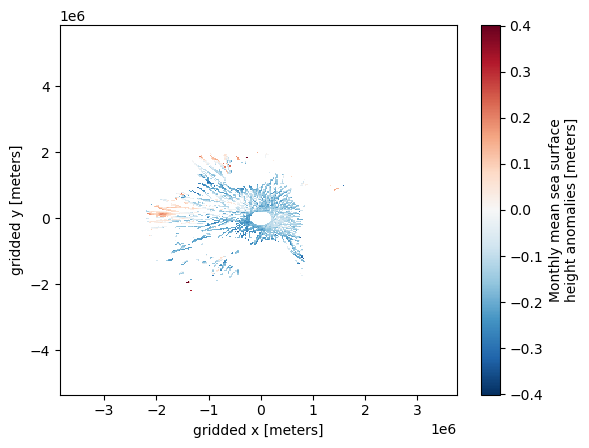

In [52]:
ds.mean_ssha.plot()

In [30]:
dt.groups

('/',
 '/ancillary_data',
 '/daily',
 '/monthly',
 '/orbit_info',
 '/quality_assessment',
 '/METADATA',
 '/ancillary_data/beam_selection',
 '/ancillary_data/refsurf_selection',
 '/daily/day14',
 '/daily/day15',
 '/daily/day16',
 '/daily/day17',
 '/daily/day18',
 '/daily/day19',
 '/daily/day20',
 '/daily/day21',
 '/daily/day22',
 '/daily/day23',
 '/daily/day24',
 '/daily/day25',
 '/daily/day26',
 '/daily/day27',
 '/daily/day28',
 '/daily/day29',
 '/daily/day30',
 '/daily/day31',
 '/METADATA/AcquisitionInformation',
 '/METADATA/DataQuality',
 '/METADATA/DatasetIdentification',
 '/METADATA/Extent',
 '/METADATA/Lineage',
 '/METADATA/ProcessStep',
 '/METADATA/ProductSpecificationDocument',
 '/METADATA/QADatasetIdentification',
 '/METADATA/SeriesIdentification',
 '/METADATA/AcquisitionInformation/lidar',
 '/METADATA/AcquisitionInformation/lidarDocument',
 '/METADATA/AcquisitionInformation/platform',
 '/METADATA/AcquisitionInformation/platformDocument',
 '/METADATA/DataQuality/CompletenessOmi

### Filter to the files you want

Once you see the files names, you can filter to the ones you want. using `granule_name`. For example `*.SNSP.*.4km.*` to get the seasonal (quarterly) values. `*` are wildcard values.

In [7]:
import point_collocation as pc
plan = pc.plan(
    df,
    data_source="earthaccess",
    source_kwargs={
        "short_name": short_name,
        "granule_name": "*.SNSP.*.4km.*"
    }
)

In [20]:
plan.summary()

Plan: 1 points → 1 unique granule(s)
  Points with 0 matches : 0
  Points with >1 matches: 0
  Variables  : []
  Time buffer: 0 days 00:00:00

First 1 point(s):
  [0] lat=30.0000, lon=-89.0000, time=2025-04-09 00:00:00: 1 match(es)
    → https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20250321_20250620.L3m.SNSP.AVW.V3_1.avw.4km.nc


In [7]:
plan.summary(n=0)

Plan: 100 points → 18 unique granule(s)
  Points with 0 matches : 0
  Points with >1 matches: 0
  Time buffer: 0 days 00:00:00


## Get matchups using that plan

In [7]:
%%time
res = pc.matchup(plan, variables = ["avw"])

CPU times: user 2.5 s, sys: 353 ms, total: 2.86 s
Wall time: 8.33 s


In [8]:
res.head()

,lat,lon,time,pc_id,granule_id,granule_time,granule_lat,granule_lon,avw
0,27.3835,-82.7375,2024-06-13 12:00:00,0,https://obdaac-tea.earthdatacloud.nasa.gov/ob-...,2024-06-13 11:59:59+00:00,27.395832,-82.729164,NaN
1,27.1190,-82.7125,2024-06-14 12:00:00,1,https://obdaac-tea.earthdatacloud.nasa.gov/ob-...,2024-06-14 11:59:59+00:00,27.104164,-82.729164,NaN
2,26.9435,-82.8170,2024-06-14 12:00:00,2,https://obdaac-tea.earthdatacloud.nasa.gov/ob-...,2024-06-14 11:59:59+00:00,26.937498,-82.812500,NaN
3,26.6875,-82.8065,2024-06-14 12:00:00,3,https://obdaac-tea.earthdatacloud.nasa.gov/ob-...,2024-06-14 11:59:59+00:00,26.687498,-82.812500,NaN
4,26.6675,-82.6455,2024-06-14 12:00:00,4,https://obdaac-tea.earthdatacloud.nasa.gov/ob-...,2024-06-14 11:59:59+00:00,26.687498,-82.645828,NaN


## collection_id = "C2237824918-ORNL_CLOUD"

Note even remotely lat, lon grid or swath. WON'T FIX


In [3]:
df = df_points[
    (df_points["time"].dt.year == 2024) &
    (df_points["land"] == True)
]
df

,lat,lon,time,land
69,10.599199,-72.685151,2024-01-21,True
184,38.125948,-118.475259,2024-04-27,True
270,-75.878023,85.292244,2024-03-16,True
457,-11.517505,30.396363,2024-07-14,True
477,-3.553879,37.489032,2024-05-19,True
558,29.394523,0.993279,2024-04-20,True
689,7.317363,1.866477,2024-10-15,True
786,34.218708,-90.668536,2024-10-29,True


In [7]:
import xarray as xr
import earthaccess
results = earthaccess.search_data(
    concept_id="C2237824918-ORNL_CLOUD",
    temporal = (df.time.iloc[0], df.time.iloc[0])
)
len(results)

1

In [8]:
f = earthaccess.open(results[0:1])

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

<xarray.Dataset> Size: 0B
Dimensions:  ()
Data variables:
    *empty*
Attributes:
    short_name:  GEDI_L4A

In [10]:
ds = xr.open_datatree(f[0], decode_timedelta=False)
ds

/tmp/ipykernel_5320/2001379186.py:1: UserWarning: The 'phony_dims' kwarg now defaults to 'access'. Previously 'phony_dims=None' would raise an error. For full netcdf equivalence please use phony_dims='sort'.
  ds = xr.open_datatree(f[0], decode_timedelta=False)


<xarray.DataTree>
Group: /
│   Attributes:
│       short_name:  GEDI_L4A
├── Group: /ANCILLARY
│       Dimensions:     (phony_dim_0: 35, phony_dim_1: 7)
│       Dimensions without coordinates: phony_dim_0, phony_dim_1
│       Data variables:
│           model_data  (phony_dim_0) [('predict_stratum', 'O'), ('model_group', 'u1'), ('model_name', 'O'), ('model_id', 'u1'), ('x_transform', 'O'), ('y_transform', 'O'), ('bias_correction_name', 'O'), ('fit_stratum', 'O'), ('rh_index', 'u1', (8,)), ('predictor_id', 'u1', (8,)), ('predictor_max_value', '<f4', (8,)), ('vcov', '<f8', (5, 5)), ('par', '<f8', (5,)), ('rse', '<f4'), ('dof', '<u4'), ('response_max_value', '<f4'), ('bias_correction_value', '<f4'), ('npar', 'u1')] 12kB ...
│           pft_lut     (phony_dim_1) [('pft_class', 'u1'), ('pft_name', 'O')] 63B ...
│           region_lut  (phony_dim_1) [('region_class', 'u1'), ('region_name', 'O')] 63B ...
├── Group: /BEAM0000
│   │   Dimensions:               (phony_dim_2: 116543, phony_dim_3: 4)
│   │   Coordinates:
│   │       delta_time            (phony_dim_2) float64 932kB ...
│   │       lat_lowestmode        (phony_dim_2) float64 932kB ...
│   │       lon_lowestmode        (phony_dim_2) float64 932kB ...
│   │   Dimensions without coordinates: phony_dim_2, phony_dim_3
│   │   Data variables: (12/26)
│   │       agbd                  (phony_dim_2) float32 466kB ...
│   │       agbd_pi_lower         (phony_dim_2) float32 466kB ...
│   │       agbd_pi_upper         (phony_dim_2) float32 466kB ...
│   │       agbd_se               (phony_dim_2) float32 466kB ...
│   │       agbd_t                (phony_dim_2) float32 466kB ...
│   │       agbd_t_se             (phony_dim_2) float32 466kB ...
│   │       ...                    ...
│   │       selected_mode_flag    (phony_dim_2) uint8 117kB ...
│   │       sensitivity           (phony_dim_2) float32 466kB ...
│   │       shot_number           (phony_dim_2) uint64 932kB ...
│   │       solar_elevation       (phony_dim_2) float32 466kB ...
│   │       surface_flag          (phony_dim_2) uint8 117kB ...
│   │       xvar                  (phony_dim_2, phony_dim_3) float32 2MB ...
│   │   Attributes:
│   │       description:  Coverage beam
│   ├── Group: /BEAM0000/agbd_prediction
│   │       Dimensions:                   (phony_dim_4: 116543, phony_dim_5: 4)
│   │       Dimensions without coordinates: phony_dim_4, phony_dim_5
│   │       Data variables: (12/113)
│   │           agbd_a1                   (phony_dim_4) float32 466kB ...
│   │           agbd_a10                  (phony_dim_4) float32 466kB ...
│   │           agbd_a2                   (phony_dim_4) float32 466kB ...
│   │           agbd_a3                   (phony_dim_4) float32 466kB ...
│   │           agbd_a4                   (phony_dim_4) float32 466kB ...
│   │           agbd_a5                   (phony_dim_4) float32 466kB ...
│   │           ...                        ...
│   │           xvar_a10                  (phony_dim_4, phony_dim_5) float32 2MB ...
│   │           xvar_a2                   (phony_dim_4, phony_dim_5) float32 2MB ...
│   │           xvar_a3                   (phony_dim_4, phony_dim_5) float32 2MB ...
│   │           xvar_a4                   (phony_dim_4, phony_dim_5) float32 2MB ...
│   │           xvar_a5                   (phony_dim_4, phony_dim_5) float32 2MB ...
│   │           xvar_a6                   (phony_dim_4, phony_dim_5) float32 2MB ...
│   │       Attributes:
│   │           alpha:                      0.1
│   │           l2a_alg_count:              7
│   │           max_nvar:                   4
│   │           pft_grid_version:           4
│   │           pft_infilled_grid_version:  6
│   │           phenology_grid_version:     5
│   │           predictor_offset:           100
│   │           region_grid_version:        5
│   │           response_offset:            0
│   │           urban_grid_version:         1
│   │           water_grid_version:         1
│   ├── Group: /BEAM0

In [4]:
import point_collocation as pc
plan = pc.plan(
    df,
    data_source="earthaccess",
    source_kwargs={
        "concept_id": "C2237824918-ORNL_CLOUD",
    }
)

In [5]:
plan.summary()

Plan: 8 points → 0 unique granule(s)
  Points with 0 matches : 8
  Points with >1 matches: 0
  Time buffer: 0 days 00:00:00

First 5 point(s):
  [69] lat=10.5992, lon=-72.6852, time=2024-01-21 00:00:00: 0 match(es)
  [184] lat=38.1259, lon=-118.4753, time=2024-04-27 00:00:00: 0 match(es)
  [270] lat=-75.8780, lon=85.2922, time=2024-03-16 00:00:00: 0 match(es)
  [457] lat=-11.5175, lon=30.3964, time=2024-07-14 00:00:00: 0 match(es)
  [477] lat=-3.5539, lon=37.4890, time=2024-05-19 00:00:00: 0 match(es)


## ECCO

In [12]:
df_points = pd.read_csv(
    "fixtures/points_1000.csv",
    parse_dates=["time"]
)
df = df_points[
    (df_points["time"].dt.year == 1992) &
    (df_points["land"] == False)
].reset_index(drop=True)
df

,lat,lon,time,land
0,-49.208746,130.302670,1992-03-23,False
1,28.169083,174.932647,1992-03-25,False
2,7.490259,-31.147141,1992-01-11,False
3,-51.149209,96.765089,1992-01-10,False
4,32.184394,-147.449519,1992-12-18,False
5,-30.461383,-1.285569,1992-01-24,False
6,-55.525274,-66.685759,1992-01-10,False
7,1.356566,-107.987387,1992-09-13,False
8,-48.149322,51.787091,1992-03-17,False
9,-34.766117,98.371848,1992-10-16,False


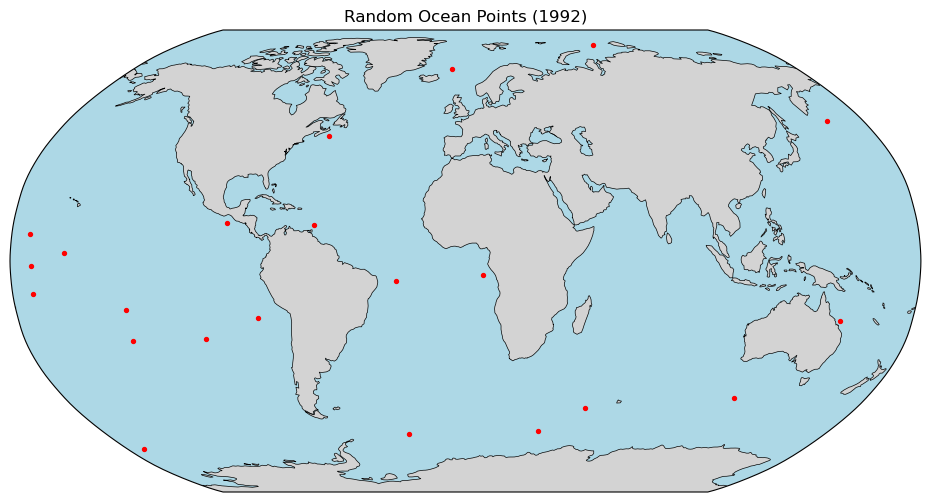

In [3]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# filter points
df = df_points[
    (df_points["time"].dt.year == 1992) &
    (~df_points["land"])
]

# create Robinson projection
proj = ccrs.Robinson()

fig = plt.figure(figsize=(12,6))
ax = plt.axes(projection=proj)

# add map features
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)

# plot points
ax.scatter(
    df["lon"],
    df["lat"],
    s=8,
    color="red",
    transform=ccrs.PlateCarree()
)

ax.set_global()
plt.title("Random Ocean Points (1992)")
plt.show()

In [4]:
import point_collocation as pc
short_name="ECCO_L4_SSH_05DEG_MONTHLY_V4R4"
plan = pc.plan(
    df,
    data_source="earthaccess",
    source_kwargs={
        "short_name": short_name,
    }
)
plan.summary()

Plan: 22 points → 11 unique granule(s)
  Points with 0 matches : 0
  Points with >1 matches: 1
  Time buffer: 0 days 00:00:00

First 5 point(s):
  [66] lat=-19.9151, lon=-83.3885, time=1992-12-16 00:00:00: 1 match(es)
    → https://archive.podaac.earthdata.nasa.gov/podaac-ops-cumulus-protected/ECCO_L4_SSH_05DEG_MONTHLY_V4R4/SEA_SURFACE_HEIGHT_mon_mean_1992-12_ECCO_V4r4_latlon_0p50deg.nc
  [75] lat=2.8745, lon=-158.7048, time=1992-03-20 00:00:00: 1 match(es)
    → https://archive.podaac.earthdata.nasa.gov/podaac-ops-cumulus-protected/ECCO_L4_SSH_05DEG_MONTHLY_V4R4/SEA_SURFACE_HEIGHT_mon_mean_1992-03_ECCO_V4r4_latlon_0p50deg.nc
  [147] lat=-11.6778, lon=-172.1407, time=1992-09-14 00:00:00: 1 match(es)
    → https://archive.podaac.earthdata.nasa.gov/podaac-ops-cumulus-protected/ECCO_L4_SSH_05DEG_MONTHLY_V4R4/SEA_SURFACE_HEIGHT_mon_mean_1992-09_ECCO_V4r4_latlon_0p50deg.nc
  [217] lat=-1.7123, lon=-171.7242, time=1992-12-09 00:00:00: 1 match(es)
    → https://archive.podaac.earthdata.nasa.g

In [14]:
plan.show_variables()

geometry     : 'grid'
open_method  : 'dataset'
Dimensions : {'time': 1, 'latitude': 360, 'longitude': 720, 'nv': 2}
Variables  : ['SSH', 'SSHIBC', 'SSHNOIBC']

Geolocation: ('longitude', 'latitude') — lon dims=('longitude',), lat dims=('latitude',)


In [5]:
%%time
res = pc.matchup(plan, variables = ["SSH"])

CPU times: user 2.18 s, sys: 158 ms, total: 2.34 s
Wall time: 5.03 s


In [6]:
res

,lat,lon,time,land,pc_id,granule_id,granule_time,granule_lat,granule_lon,SSH
0,68.818342,-7.273068,1992-01-26,False,703,https://archive.podaac.earthdata.nasa.gov/poda...,1992-01-16 18:00:00+00:00,68.75,-7.25,-0.781884
1,-47.800668,120.321372,1992-02-08,False,495,https://archive.podaac.earthdata.nasa.gov/poda...,1992-02-15 12:00:00+00:00,-47.75,120.25,0.016839
2,2.874521,-158.704773,1992-03-20,False,75,https://archive.podaac.earthdata.nasa.gov/poda...,1992-03-16 12:00:00+00:00,2.75,-158.75,0.603334
3,-20.990884,150.910649,1992-04-15,False,224,https://archive.podaac.earthdata.nasa.gov/poda...,1992-04-16 00:00:00+00:00,-20.75,150.75,0.731124
4,-67.251397,-171.320942,1992-04-11,False,277,https://archive.podaac.earthdata.nasa.gov/poda...,1992-04-16 00:00:00+00:00,-67.25,-171.25,-1.572482
5,-4.801420,6.959748,1992-04-29,False,382,https://archive.podaac.earthdata.nasa.gov/poda...,1992-04-16 00:00:00+00:00,-4.75,6.75,0.031338
6,-17.262822,-136.033246,1992-04-30,False,676,https://archive.podaac.earthdata.nasa.gov/poda...,1992-04-16 00:00:00+00:00,-17.25,-136.25,0.705870
7,43.852275,-59.583430,1992-04-19,False,833,https://archive.podaac.earthdata.nasa.gov/poda...,1992-04-16 00:00:00+00:00,43.75,-59.75,-0.583091
8,-27.919489,-136.118250,1992-05-23,False,375,https://archive.podaac.earthdata.nasa.gov/poda...,1992-05-16 12:00:00+00:00,-27.75,-136.25,0.544468
9,48.952954,163.570656,1992-06-01,False,531,https://archive.podaac.earthdata.nasa.gov/poda...,1992-05-16 12:00:00+00:00,48.75,163.75,-0.161831


In [11]:
import xarray as xr
import earthaccess
results = earthaccess.search_data(
    short_name="ECCO_L4_SSH_05DEG_MONTHLY_V4R4",
    temporal = (df.time.iloc[0], df.time.iloc[0])
)
f = earthaccess.open(results[0:1])
ds = xr.open_dataset(f[0])
ds.SSH.sel(latitude=df.lat.iloc[0], longitude=df.lon.iloc[0], method="nearest").values

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

array([0.23669547], dtype=float32)

In [9]:
df.time.iloc[0]

Timestamp('1992-12-16 00:00:00')

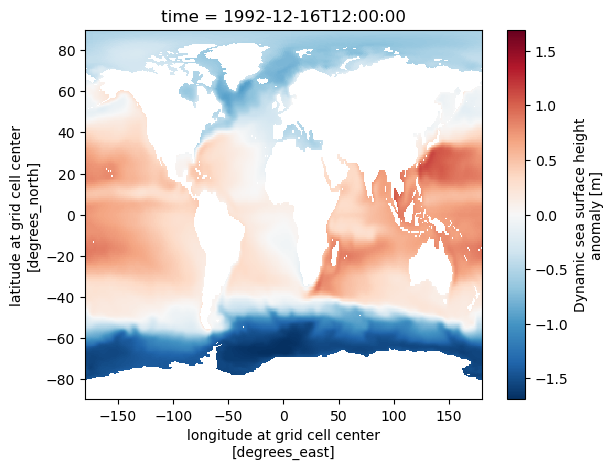

In [22]:
ds.SSH.plot()

In [28]:
ds.SSH.sel(latitude=df.lat.iloc[0], longitude=df.lon.iloc[0], method="nearest").values

array([0.10287101], dtype=float32)

In [26]:
df.lon.iloc[0]

np.float64(-107.62675250689612)

## MUR SST

* short_name="MUR-JPL-L4-GLOB-v4.1" level 4 SST

* short_name="MUR25-JPL-L4-GLOB-v04.2" level 4 SST

In [11]:
df_points = pd.read_csv(
    "fixtures/points_1000.csv",
    parse_dates=["time"]
)
df = df_points[
    (df_points["time"].dt.year == 2024) &
    (df_points["land"] == False)
].reset_index(drop=True)
df

,lat,lon,time,land
0,-67.209878,-62.734423,2024-04-16,False
1,87.228338,-29.718344,2024-10-13,False
2,34.701655,-20.040258,2024-04-21,False
3,-8.043907,41.779801,2024-08-31,False
4,6.631233,-138.494233,2024-05-08,False
5,-20.064168,-173.807753,2024-02-16,False
6,-57.605068,12.223938,2024-04-12,False
7,34.247526,-166.904639,2024-08-21,False
8,18.685278,-67.641855,2024-03-28,False
9,84.699959,42.721278,2024-07-17,False


In [8]:
import point_collocation as pc
short_name="MUR-JPL-L4-GLOB-v4.1"
plan = pc.plan(
    df,
    data_source="earthaccess",
    source_kwargs={
        "short_name": short_name,
    }
)
plan.summary()

Plan: 22 points → 21 unique granule(s)
  Points with 0 matches : 0
  Points with >1 matches: 0
  Time buffer: 0 days 00:00:00

First 5 point(s):
  [28] lat=-11.1527, lon=82.7665, time=2024-09-17 00:00:00: 1 match(es)
    → https://archive.podaac.earthdata.nasa.gov/podaac-ops-cumulus-protected/MUR-JPL-L4-GLOB-v4.1/20240917090000-JPL-L4_GHRSST-SSTfnd-MUR-GLOB-v02.0-fv04.1.nc
  [127] lat=-55.8639, lon=-78.0021, time=2024-05-24 00:00:00: 1 match(es)
    → https://archive.podaac.earthdata.nasa.gov/podaac-ops-cumulus-protected/MUR-JPL-L4-GLOB-v4.1/20240524090000-JPL-L4_GHRSST-SSTfnd-MUR-GLOB-v02.0-fv04.1.nc
  [157] lat=0.2829, lon=-109.7569, time=2024-02-01 00:00:00: 1 match(es)
    → https://archive.podaac.earthdata.nasa.gov/podaac-ops-cumulus-protected/MUR-JPL-L4-GLOB-v4.1/20240201090000-JPL-L4_GHRSST-SSTfnd-MUR-GLOB-v02.0-fv04.1.nc
  [165] lat=-26.4759, lon=-77.7499, time=2024-10-23 00:00:00: 1 match(es)
    → https://archive.podaac.earthdata.nasa.gov/podaac-ops-cumulus-protected/MUR-JPL-

In [9]:
plan.show_variables()

geometry     : 'grid'
open_method  : 'dataset'


/home/jovyan/point-collocation/src/point_collocation/core/plan.py:470: FutureWarning: In a future version, xarray will not decode the variable 'dt_1km_data' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds_flat = xr.open_dataset(file_obj, **kwargs)  # type: ignore[arg-type]


Dimensions : {'time': 1, 'lat': 17999, 'lon': 36000}
Variables  : ['analysed_sst', 'analysis_error', 'mask', 'sea_ice_fraction', 'dt_1km_data', 'sst_anomaly']

Geolocation: ('lon', 'lat') — lon dims=('lon',), lat dims=('lat',)


In [10]:
%%time
res = pc.matchup(plan, variables = ["analysed_sst"])
res

/home/jovyan/point-collocation/src/point_collocation/core/engine.py:497: FutureWarning: In a future version, xarray will not decode the variable 'dt_1km_data' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  with xr.open_dataset(file_obj, **kwargs) as ds:  # type: ignore[arg-type]
/home/jovyan/point-collocation/src/point_collocation/core/engine.py:497: FutureWarning: In a future version, xarray will not decode the variable 'dt_1km_data' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the pre

CPU times: user 6.55 s, sys: 1.79 s, total: 8.33 s
Wall time: 34 s


,lat,lon,time,land,pc_id,granule_id,granule_time,granule_lat,granule_lon,analysed_sst
0,0.282850,-109.756855,2024-02-01,False,157,https://archive.podaac.earthdata.nasa.gov/poda...,2024-02-01 09:00:00+00:00,0.280000,-109.760002,300.271
1,47.246201,-157.731765,2024-02-02,False,786,https://archive.podaac.earthdata.nasa.gov/poda...,2024-02-02 09:00:00+00:00,47.250000,-157.729996,279.360
2,19.473225,-56.276119,2024-02-18,False,658,https://archive.podaac.earthdata.nasa.gov/poda...,2024-02-18 09:00:00+00:00,19.469999,-56.279999,299.637
3,-59.220576,-88.712641,2024-02-22,False,725,https://archive.podaac.earthdata.nasa.gov/poda...,2024-02-22 09:00:00+00:00,-59.220001,-88.709999,278.401
4,49.130090,168.960272,2024-03-25,False,993,https://archive.podaac.earthdata.nasa.gov/poda...,2024-03-25 09:00:00+00:00,49.130001,168.960007,275.937
5,-59.832796,-132.928057,2024-04-06,False,939,https://archive.podaac.earthdata.nasa.gov/poda...,2024-04-06 09:00:00+00:00,-59.830002,-132.929993,276.149
6,11.593167,-126.863850,2024-04-12,False,224,https://archive.podaac.earthdata.nasa.gov/poda...,2024-04-12 09:00:00+00:00,11.590000,-126.860001,300.258
7,60.586935,-12.237935,2024-05-06,False,179,https://archive.podaac.earthdata.nasa.gov/poda...,2024-05-06 09:00:00+00:00,60.590000,-12.240000,282.405
8,-51.465215,39.262678,2024-05-16,False,177,https://archive.podaac.earthdata.nasa.gov/poda...,2024-05-16 09:00:00+00:00,-51.470001,39.259998,276.571
9,4.128974,-35.368958,2024-05-16,False,265,https://archive.podaac.earthdata.nasa.gov/poda...,2024-05-16 09:00:00+00:00,4.130000,-35.369999,302.957


In [11]:
import point_collocation as pc
short_name="MUR25-JPL-L4-GLOB-v04.2"
plan = pc.plan(
    df,
    data_source="earthaccess",
    source_kwargs={
        "short_name": short_name,
    }
)
plan.summary()

Plan: 22 points → 21 unique granule(s)
  Points with 0 matches : 0
  Points with >1 matches: 0
  Time buffer: 0 days 00:00:00

First 5 point(s):
  [28] lat=-11.1527, lon=82.7665, time=2024-09-17 00:00:00: 1 match(es)
    → https://archive.podaac.earthdata.nasa.gov/podaac-ops-cumulus-protected/MUR25-JPL-L4-GLOB-v04.2/20240917090000-JPL-L4_GHRSST-SSTfnd-MUR25-GLOB-v02.0-fv04.2.nc
  [127] lat=-55.8639, lon=-78.0021, time=2024-05-24 00:00:00: 1 match(es)
    → https://archive.podaac.earthdata.nasa.gov/podaac-ops-cumulus-protected/MUR25-JPL-L4-GLOB-v04.2/20240524090000-JPL-L4_GHRSST-SSTfnd-MUR25-GLOB-v02.0-fv04.2.nc
  [157] lat=0.2829, lon=-109.7569, time=2024-02-01 00:00:00: 1 match(es)
    → https://archive.podaac.earthdata.nasa.gov/podaac-ops-cumulus-protected/MUR25-JPL-L4-GLOB-v04.2/20240201090000-JPL-L4_GHRSST-SSTfnd-MUR25-GLOB-v02.0-fv04.2.nc
  [165] lat=-26.4759, lon=-77.7499, time=2024-10-23 00:00:00: 1 match(es)
    → https://archive.podaac.earthdata.nasa.gov/podaac-ops-cumulus-pro

In [12]:
plan.show_variables()

geometry     : 'grid'
open_method  : 'dataset'
Dimensions : {'time': 1, 'lat': 720, 'lon': 1440}
Variables  : ['analysed_sst', 'analysis_error', 'mask', 'sea_ice_fraction', 'sst_anomaly']

Geolocation: ('lon', 'lat') — lon dims=('lon',), lat dims=('lat',)


In [15]:
%%time
res = pc.matchup(plan, variables = ["sea_ice_fraction", 'analysed_sst', 'analysis_error'])
res

CPU times: user 2.36 s, sys: 23.9 ms, total: 2.38 s
Wall time: 4.28 s


,lat,lon,time,land,pc_id,granule_id,granule_time,granule_lat,granule_lon,sea_ice_fraction,analysed_sst,analysis_error
0,0.282850,-109.756855,2024-02-01,False,157,https://archive.podaac.earthdata.nasa.gov/poda...,2024-02-01 09:00:00+00:00,0.375,-109.875,NaN,299.905,0.36
1,47.246201,-157.731765,2024-02-02,False,786,https://archive.podaac.earthdata.nasa.gov/poda...,2024-02-02 09:00:00+00:00,47.125,-157.625,NaN,279.746,0.38
2,19.473225,-56.276119,2024-02-18,False,658,https://archive.podaac.earthdata.nasa.gov/poda...,2024-02-18 09:00:00+00:00,19.375,-56.375,NaN,299.605,0.37
3,-59.220576,-88.712641,2024-02-22,False,725,https://archive.podaac.earthdata.nasa.gov/poda...,2024-02-22 09:00:00+00:00,-59.125,-88.625,NaN,278.535,0.37
4,49.130090,168.960272,2024-03-25,False,993,https://archive.podaac.earthdata.nasa.gov/poda...,2024-03-25 09:00:00+00:00,49.125,168.875,NaN,275.956,0.38
5,-59.832796,-132.928057,2024-04-06,False,939,https://archive.podaac.earthdata.nasa.gov/poda...,2024-04-06 09:00:00+00:00,-59.875,-132.875,NaN,276.130,0.37
6,11.593167,-126.863850,2024-04-12,False,224,https://archive.podaac.earthdata.nasa.gov/poda...,2024-04-12 09:00:00+00:00,11.625,-126.875,NaN,300.275,0.38
7,60.586935,-12.237935,2024-05-06,False,179,https://archive.podaac.earthdata.nasa.gov/poda...,2024-05-06 09:00:00+00:00,60.625,-12.125,NaN,282.483,0.37
8,-51.465215,39.262678,2024-05-16,False,177,https://archive.podaac.earthdata.nasa.gov/poda...,2024-05-16 09:00:00+00:00,-51.375,39.375,NaN,276.518,0.38
9,4.128974,-35.368958,2024-05-16,False,265,https://archive.podaac.earthdata.nasa.gov/poda...,2024-05-16 09:00:00+00:00,4.125,-35.375,NaN,302.699,0.38


## short_name = "TEMPO_NO2_L3", version = "V03"

In [1]:
import pandas as pd
df_points = pd.read_csv(
    "fixtures/points_1000_usa.csv",
    parse_dates=["time"]
)
df = df_points[
    (df_points["time"].dt.year == 2024) &
    (df_points["land"] == True)
]
len(df)

28

In [2]:
import point_collocation as pc
short_name="TEMPO_NO2_L3"
plan = pc.plan(
    df,
    data_source="earthaccess",
    source_kwargs={
        "short_name": short_name,
        "version": "V03"
    },
    time_buffer="1h"
)
plan.summary()

Plan: 28 points → 30 unique granule(s)
  Points with 0 matches : 17
  Points with >1 matches: 10
  Time buffer: 0 days 01:00:00

First 5 point(s):
  [5] lat=42.9192, lon=-107.1190, time=2024-02-07 19:04:58: 3 match(es)
    → https://data.asdc.earthdata.nasa.gov/asdc-prod-protected/TEMPO/TEMPO_NO2_L3_V03/2024.02.07/TEMPO_NO2_L3_V03_20240207T172301Z_S007.nc
    → https://data.asdc.earthdata.nasa.gov/asdc-prod-protected/TEMPO/TEMPO_NO2_L3_V03/2024.02.07/TEMPO_NO2_L3_V03_20240207T182301Z_S008.nc
    → https://data.asdc.earthdata.nasa.gov/asdc-prod-protected/TEMPO/TEMPO_NO2_L3_V03/2024.02.07/TEMPO_NO2_L3_V03_20240207T192301Z_S009.nc
  [22] lat=32.0338, lon=-87.5042, time=2024-03-12 19:18:24: 2 match(es)
    → https://data.asdc.earthdata.nasa.gov/asdc-prod-protected/TEMPO/TEMPO_NO2_L3_V03/2024.03.12/TEMPO_NO2_L3_V03_20240312T174835Z_S009.nc
    → https://data.asdc.earthdata.nasa.gov/asdc-prod-protected/TEMPO/TEMPO_NO2_L3_V03/2024.03.12/TEMPO_NO2_L3_V03_20240312T184835Z_S010.nc
  [106] lat=44

In [42]:
plan.show_variables()

geometry     : 'grid'
open_method  : 'dataset'
Dimensions : {'latitude': 2950, 'longitude': 7750, 'time': 1}
Variables  : ['weight']

Geolocation: ('longitude', 'latitude') — lon dims=('longitude',), lat dims=('latitude',)


In [3]:
%%time
res = pc.matchup(plan, variables = ["weight"], batch_size=1, silent=False)
res

granules 1-1 of 30 processed, 1 points matched, 00:00:06
granules 2-2 of 30 processed, 1 points matched, 00:00:09
granules 3-3 of 30 processed, 1 points matched, 00:00:11
granules 4-4 of 30 processed, 1 points matched, 00:00:15
granules 5-5 of 30 processed, 1 points matched, 00:00:17
granules 6-6 of 30 processed, 1 points matched, 00:00:20
granules 7-7 of 30 processed, 1 points matched, 00:00:22
granules 8-8 of 30 processed, 1 points matched, 00:00:25
granules 9-9 of 30 processed, 1 points matched, 00:00:28
granules 10-10 of 30 processed, 1 points matched, 00:00:30
granules 11-11 of 30 processed, 1 points matched, 00:00:33
granules 12-12 of 30 processed, 1 points matched, 00:00:35
granules 13-13 of 30 processed, 1 points matched, 00:00:38
granules 14-14 of 30 processed, 1 points matched, 00:00:41
granules 15-15 of 30 processed, 1 points matched, 00:00:43
granules 16-16 of 30 processed, 1 points matched, 00:00:47
granules 17-17 of 30 processed, 1 points matched, 00:00:50
granules 18-18 

,lat,lon,time,land,pc_id,granule_id,granule_lat,granule_lon,granule_time,weight
0,29.592103,-95.889008,2024-03-30 03:06:23,True,138,NaN,NaN,NaN,NaT,NaN
1,37.789200,-98.045855,2024-01-26 18:04:05,True,159,NaN,NaN,NaN,NaT,NaN
2,39.294678,-78.733102,2024-01-22 08:05:14,True,226,NaN,NaN,NaN,NaT,NaN
3,47.990960,-121.418745,2024-01-14 10:17:36,True,321,NaN,NaN,NaN,NaT,NaN
4,71.106104,-157.164729,2024-02-23 20:29:20,True,381,NaN,NaN,NaN,NaT,NaN
5,43.615604,-111.837185,2024-12-05 01:10:03,True,388,NaN,NaN,NaN,NaT,NaN
6,35.657049,-105.120080,2024-11-04 08:32:44,True,392,NaN,NaN,NaN,NaT,NaN
7,48.462016,-110.181988,2024-08-14 09:04:20,True,498,NaN,NaN,NaN,NaT,NaN
8,65.773816,-162.396664,2024-09-03 05:34:34,True,607,NaN,NaN,NaN,NaT,NaN
9,34.594870,-81.136749,2024-01-03 23:56:28,True,690,NaN,NaN,NaN,NaT,NaN


In [3]:
%%time
res = pc.matchup(plan, variables = ["weight"])
res

CPU times: user 17.7 s, sys: 2.85 s, total: 20.5 s
Wall time: 1min 50s


,lat,lon,time,land,pc_id,granule_id,granule_lat,granule_lon,granule_time,weight
0,29.592103,-95.889008,2024-03-30 03:06:23,True,138,NaN,NaN,NaN,NaT,NaN
1,37.789200,-98.045855,2024-01-26 18:04:05,True,159,NaN,NaN,NaN,NaT,NaN
2,39.294678,-78.733102,2024-01-22 08:05:14,True,226,NaN,NaN,NaN,NaT,NaN
3,47.990960,-121.418745,2024-01-14 10:17:36,True,321,NaN,NaN,NaN,NaT,NaN
4,71.106104,-157.164729,2024-02-23 20:29:20,True,381,NaN,NaN,NaN,NaT,NaN
5,43.615604,-111.837185,2024-12-05 01:10:03,True,388,NaN,NaN,NaN,NaT,NaN
6,35.657049,-105.120080,2024-11-04 08:32:44,True,392,NaN,NaN,NaN,NaT,NaN
7,48.462016,-110.181988,2024-08-14 09:04:20,True,498,NaN,NaN,NaN,NaT,NaN
8,65.773816,-162.396664,2024-09-03 05:34:34,True,607,NaN,NaN,NaN,NaT,NaN
9,34.594870,-81.136749,2024-01-03 23:56:28,True,690,NaN,NaN,NaN,NaT,NaN


In [4]:
import xarray as xr
import earthaccess
results = earthaccess.search_data(
    short_name="TEMPO_NO2_L3",
    temporal = (df.time.iloc[0], df.time.iloc[0]),
    version = "V03"
)
f = earthaccess.open(results[0:1])
ds = xr.open_dataset(f[0])
ds

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

<xarray.Dataset> Size: 91MB
Dimensions:    (latitude: 2950, longitude: 7750, time: 1)
Coordinates:
  * latitude   (latitude) float32 12kB 14.01 14.03 14.05 ... 72.95 72.97 72.99
  * longitude  (longitude) float32 31kB -168.0 -168.0 -167.9 ... -13.03 -13.01
  * time       (time) datetime64[ns] 8B 2024-02-07T18:23:19.149168128
Data variables:
    weight     (latitude, longitude) float32 91MB ...
Attributes: (12/40)
    history:                          2024-08-13T05:09:04Z: L2_regrid -v /tem...
    scan_num:                         8
    time_coverage_start:              2024-02-07T18:23:01Z
    time_coverage_end:                2024-02-07T19:22:42Z
    time_coverage_start_since_epoch:  1391365399.149168
    time_coverage_end_since_epoch:    1391368980.7623076
    ...                               ...
    title:                            TEMPO Level 3 nitrogen dioxide product
    collection_shortname:             TEMPO_NO2_L3
    collection_version:               1
    keywords:                         EARTH SCIENCE>ATMOSPHERE>AIR QUALITY>NI...
    summary:                          Nitrogen dioxide Level 3 files provide ...
    coremetadata:                     \nGROUP                  = INVENTORYMET...

In [4]:
ds.weight.sel(latitude=df.lat.iloc[0], longitude=df.lon.iloc[0], method="nearest").values

array(3.6286705, dtype=float32)

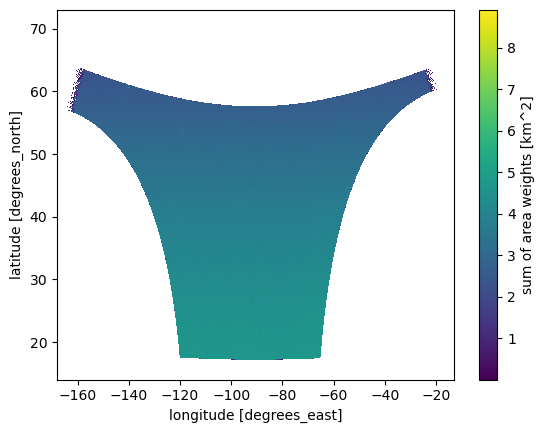

In [5]:
ds.weight.plot()

In [5]:
ds.nbytes

91492808

In [6]:
print(ds)

<xarray.Dataset> Size: 91MB
Dimensions:    (latitude: 2950, longitude: 7750, time: 1)
Coordinates:
  * latitude   (latitude) float32 12kB 14.01 14.03 14.05 ... 72.95 72.97 72.99
  * longitude  (longitude) float32 31kB -168.0 -168.0 -167.9 ... -13.03 -13.01
  * time       (time) datetime64[ns] 8B 2024-02-07T18:23:19.149168128
Data variables:
    weight     (latitude, longitude) float32 91MB ...
Attributes: (12/40)
    history:                          2024-08-13T05:09:04Z: L2_regrid -v /tem...
    scan_num:                         8
    time_coverage_start:              2024-02-07T18:23:01Z
    time_coverage_end:                2024-02-07T19:22:42Z
    time_coverage_start_since_epoch:  1391365399.149168
    time_coverage_end_since_epoch:    1391368980.7623076
    ...                               ...
    title:                            TEMPO Level 3 nitrogen dioxide product
    collection_shortname:             TEMPO_NO2_L3
    collection_version:               1
    keywords:        

## MIL3YAEN

In [9]:
import pandas as pd
df_points = pd.read_csv(
    "fixtures/points_1000_usa.csv",
    parse_dates=["time"]
)
df = df_points[
    (df_points["time"].dt.year == 2019) &
    (df_points["land"] == True)
]
len(df)

33

In [10]:
import xarray as xr
import earthaccess
results = earthaccess.search_data(
    short_name="MIL3YAEN",
    temporal = (df.time.iloc[0], df.time.iloc[0]),
)
f = earthaccess.open(results[0:1])

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

<xarray.Dataset> Size: 0B
Dimensions:  ()
Data variables:
    *empty*
Attributes: (12/16)
    Local_granule_id:                 MISR_AM1_CGAS_2019_F15_0032.nc
    Local_version_id:                 MISR_EXEC_VERSION: V6.0.7 MISR_EXEC_NAM...
    PGE_version:                      V6.0.7
    Range_beginning_time:             2018-12-01T00:00:00Z
    Range_ending_time:                2019-11-30T23:59:59Z
    Software_version_information:     Version V6.0.7\nversion info created Tu...
    ...                               ...
    Conventions:                      CF-1.6
    title:                            MISR Level 3 Component Global Aerosol P...
    institution:                      MISR Level 3 Component Global Aerosol P...
    source:                           Aerosol retrievals are obtained from th...
    history:                          2020-01-24T19:28:39 : Initial productio...
    references:                       Data Product Specifications and Algorit...

In [11]:
ds = xr.open_datatree(f[0])
ds

<xarray.DataTree>
Group: /
│   Attributes: (12/16)
│       Local_granule_id:                 MISR_AM1_CGAS_2019_F15_0032.nc
│       Local_version_id:                 MISR_EXEC_VERSION: V6.0.7 MISR_EXEC_NAM...
│       PGE_version:                      V6.0.7
│       Range_beginning_time:             2018-12-01T00:00:00Z
│       Range_ending_time:                2019-11-30T23:59:59Z
│       Software_version_information:     Version V6.0.7\nversion info created Tu...
│       ...                               ...
│       Conventions:                      CF-1.6
│       title:                            MISR Level 3 Component Global Aerosol P...
│       institution:                      MISR Level 3 Component Global Aerosol P...
│       source:                           Aerosol retrievals are obtained from th...
│       history:                          2020-01-24T19:28:39 : Initial productio...
│       references:                       Data Product Specifications and Algorit...
├── Group: /Source_file
│       Dimensions:           (Index: 5297)
│       Coordinates:
│         * Index             (Index) int32 21kB 1 2 3 4 5 ... 5293 5294 5295 5296 5297
│       Data variables:
│           Orbit_Number      (Index) int32 21kB ...
│           Path_Number       (Index) uint8 5kB ...
│           Local_Granule_Id  (Index) object 42kB ...
│           Local_Version_Id  (Index) object 42kB ...
├── Group: /Aerosol_Parameter_Average
│       Dimensions:                                                (Latitude: 360,
│                                                                   Longitude: 720,
│                                                                   Optical_Depth_Range: 9,
│                                                                   Coefficient: 3,
│                                                                   Band: 4,
│                                                                   Algorithm_Type: 3,
│                                                                   Retrieval_Success_Type: 2)
│       Coordinates:
│         * Latitude                                               (Latitude) float64 3kB ...
│         * Longitude                                              (Longitude) float64 6kB ...
│         * Optical_Depth_Range                                    (Optical_Depth_Range) object 72B ...
│         * Coefficient                                            (Coefficient) object 24B ...
│         * Band                                                   (Band) object 32B ...
│         * Algorithm_Type                                         (Algorithm_Type) object 24B ...
│         * Retrieval_Success_Type                                 (Retrieval_Success_Type) object 16B ...
│       Data variables: (12/28)
│           crs                                                    int32 4B ...
│           Absorbing_Optical_Depth                                (Latitude, Longitude, Optical_Depth_Range) float32 9MB ...
│           Absorbing_Optical_Depth_Count                          (Latitude, Longitude, Optical_Depth_Range) float64 19MB ...
│           Absorbing_Optical_Depth_Standard_Deviation             (Latitude, Longitude, Optical_Depth_Range) float32 9MB ...
│           Aerosol_Optical_Depth                                  (Latitude, Longitude, Optical_Depth_Range) float32 9MB ...
│           Aerosol_Optical_Depth_Count                            (Latitude, Longitude, Optical_Depth_Range) float64 19MB ...
│           ...                                                     ...
│           Aerosol_Optical_Depth_Per_Band                         (Latitude, Longitude, Optical_Depth_Range, Band) float32 37MB ...
│           Aerosol_Optical_Depth_Per_Band_Count                   (Latitude, Longitude, Optical_Depth_Range, Band) float64 75MB ...
│           Absorbing_Aerosol_Optical_Depth_Per_Band               (Latitude, Longitude, Optical_Depth_Range, Band) float32 37MB ...
│           Absorbing_Aerosol_Optical

In [ ]:
dt = xr.open_datatree(f[1], decode_timedelta=False, phony_dims='sort')
ds = xr.merge(
    [dt["/Aerosol_Parameter_Average"].ds, dt["/monthly"].ds]
)
ds = ds.set_coords(["grid_lat", "grid_lon"])
ds

## MOP03JM

In [17]:
import xarray as xr
import earthaccess
results = earthaccess.search_data(
    short_name="MOP03JM",
    temporal = ("2024-10-01", "2024-12-31"),
    version = "9"
)
f = earthaccess.open(results[0:1])
f

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

[<File-like object S3FileSystem, asdc-prod-protected/MOPITT/MOP03JM.9/2024.10.01/MOP03JM-202410-L3V95.10.3.he5>]

In [19]:
dt = xr.open_datatree(f[0])
dt

/tmp/ipykernel_6661/1903594676.py:1: UserWarning: The 'phony_dims' kwarg now defaults to 'access'. Previously 'phony_dims=None' would raise an error. For full netcdf equivalence please use phony_dims='sort'.
  dt = xr.open_datatree(f[0])


<xarray.DataTree>
Group: /
├── Group: /HDFEOS
│   ├── Group: /HDFEOS/ADDITIONAL
│   │   └── Group: /HDFEOS/ADDITIONAL/FILE_ATTRIBUTES
│   │           Attributes:
│   │               FillValue:    -9999.0
│   │               StartTime:    1001894415.832
│   │               StopTime:     1004570188.0299994
│   │               institution:  MOPITT at ACOM of NCAR
│   │               title:        MOPITT Level 3 Monthly File
│   └── Group: /HDFEOS/GRIDS
│       └── Group: /HDFEOS/GRIDS/MOP03
│           │   Dimensions:  (NTWO: 2, Prs: 9, Prs1: 10, Prs2: 10, XDim: 360, YDim: 180)
│           │   Coordinates:
│           │     * NTWO     (NTWO) int32 8B 0 1
│           │     * Prs      (Prs) float32 36B 900.0 800.0 700.0 600.0 ... 300.0 200.0 100.0
│           │     * Prs1     (Prs1) float32 40B 1e+03 900.0 800.0 700.0 ... 300.0 200.0 100.0
│           │     * Prs2     (Prs2) float32 40B 1e+03 900.0 800.0 700.0 ... 300.0 200.0 100.0
│           │     * XDim     (XDim) float64 3kB -180.0 -179.0 -178.0 ... 177.0 178.0 179.0
│           │     * YDim     (YDim) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 86.0 87.0 88.0 89.0
│           └── Group: /HDFEOS/GRIDS/MOP03/Data Fields
│                   Dimensions:                                            (XDim: 360, YDim: 180,
│                                                                           Prs: 9, Prs1: 10,
│                                                                           Prs2: 10, NTWO: 2)
│                   Data variables: (12/80)
│                       APrioriCOMixingRatioProfileDay                     (XDim, YDim, Prs) float32 2MB ...
│                       APrioriCOMixingRatioProfileNight                   (XDim, YDim, Prs) float32 2MB ...
│                       APrioriCOSurfaceMixingRatioDay                     (XDim, YDim) float32 259kB ...
│                       APrioriCOSurfaceMixingRatioNight                   (XDim, YDim) float32 259kB ...
│                       APrioriCOTotalColumnDay                            (XDim, YDim) float32 259kB ...
│                       APrioriCOTotalColumnNight                          (XDim, YDim) float32 259kB ...
│                       ...                                                 ...
│                       SurfacePressureDay                                 (XDim, YDim) float32 259kB ...
│                       SurfacePressureNight                               (XDim, YDim) float32 259kB ...
│                       TotalColumnAveragingKernelDay                      (XDim, YDim, Prs1) float32 3MB ...
│                       TotalColumnAveragingKernelNight                    (XDim, YDim, Prs1) float32 3MB ...
│                       WaterVaporColumnDay                                (XDim, YDim) float32 259kB ...
│                       WaterVaporColumnNight                              (XDim, YDim) float32 259kB ...
└── Group: /HDFEOS INFORMATION
        Dimensions:           (phony_dim_0: 1)
        Dimensions without coordinates: phony_dim_0
        Data variables:
            StructMetadata.0  |S32000 32kB ...
            coremetadata.0    (phony_dim_0) |S7571 8kB ...
        Attributes:
            HDFEOSVersion:  HDFEOS_5.1.16